<>:31: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:31: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\s'
C:\Users\UsuarioCompuElite\AppData\Local\Temp\ipykernel_9012\808224923.py:31: SyntaxWarning: invalid escape sequence '\s'
  plt.title('Valores Singulares $\sigma_k$')
C:\Users\UsuarioCompuElite\AppData\Local\Temp\ipykernel_9012\808224923.py:33: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Valor de $\sigma$')


downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\UsuarioCompuElite\scikit_learn_data


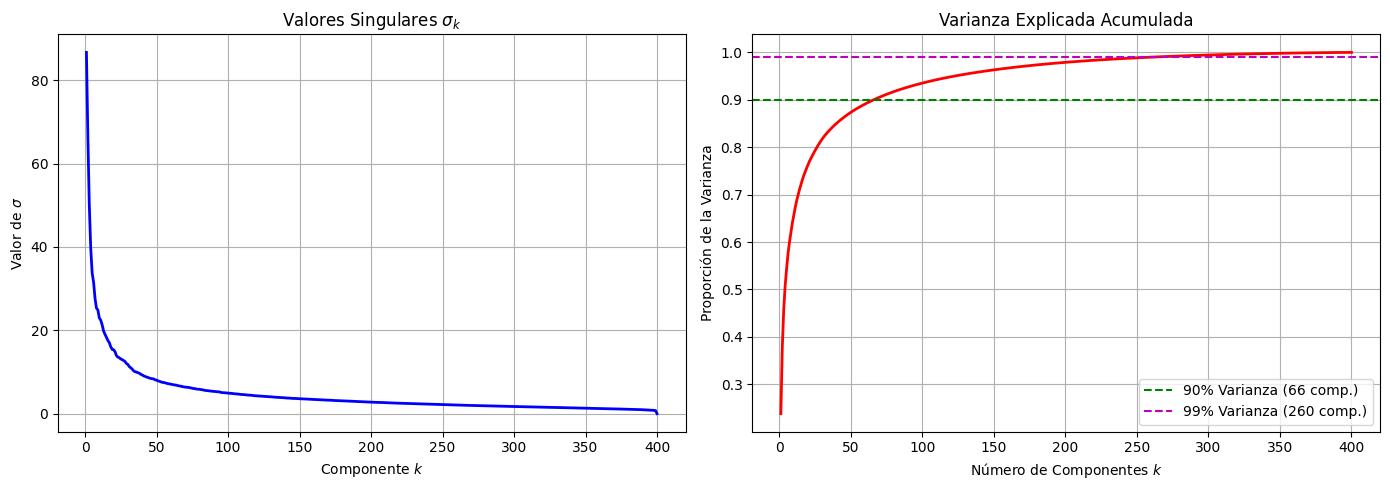

Se necesitan 66 componentes para explicar el 90% de la varianza.
Se necesitan 260 componentes para explicar el 99% de la varianza.


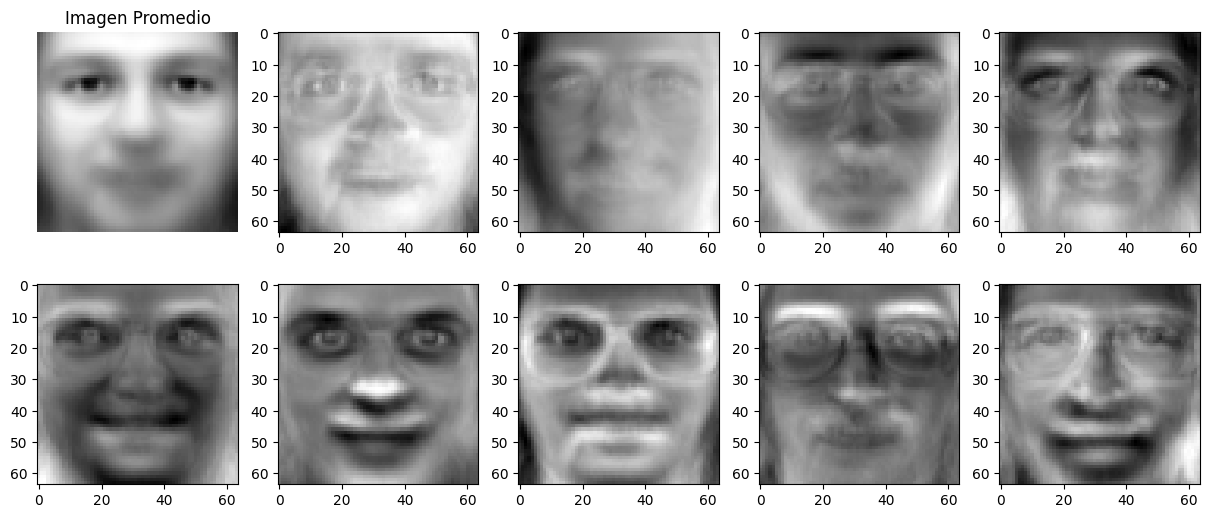

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

data = fetch_olivetti_faces(shuffle=True, random_state=42)
X = data.data
images = data.images
n_samples, n_features = X.shape
h, w = 64, 64

mean_face = np.mean(X, axis=0)
X_centered = X - mean_face

U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

eigenvalues = S ** 2
explained_variance = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

k_90 = np.argmax(cumulative_variance >= 0.90) + 1
k_99 = np.argmax(cumulative_variance >= 0.99) + 1

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(S) + 1), S, 'b-', linewidth=2)
plt.title('Valores Singulares $\sigma_k$')
plt.xlabel('Componente $k$')
plt.ylabel('Valor de $\sigma$')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'r-', linewidth=2)
plt.axhline(y=0.90, color='g', linestyle='--', label=f'90% Varianza ({k_90} comp.)')
plt.axhline(y=0.99, color='m', linestyle='--', label=f'99% Varianza ({k_99} comp.)')
plt.title('Varianza Explicada Acumulada')
plt.xlabel('Número de Componentes $k$')
plt.ylabel('Proporción de la Varianza')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('varianza_explicada.png')
plt.show()

print(f"Se necesitan {k_90} componentes para explicar el 90% de la varianza.")
print(f"Se necesitan {k_99} componentes para explicar el 99% de la varianza.")

plt.figure(figsize=(15, 6))
plt.subplot(2, 5, 1)
plt.imshow(mean_face.reshape(h, w), cmap='gray')
plt.title('Imagen Promedio')
plt.axis('off')

for i in range(9):
    plt.subplot(2, 5, i + 2)
    plt.imshow(Vt[i, :].reshape(h, w), cmap='gray')

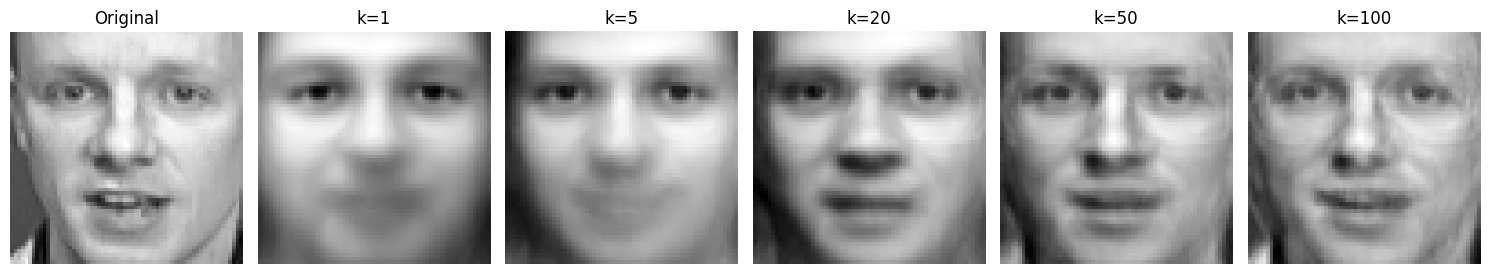

In [ ]:
def reconstruir_imagen(idx, ks=[1, 5, 20, 50, 100]):
    x_orig = X[idx]
    x_centered = x_orig - mean_face
    z = np.dot(x_centered, Vt.T)
    plt.figure(figsize=(15, 3))
    plt.subplot(1, len(ks) + 1, 1)
    plt.imshow(x_orig.reshape(h, w), cmap='gray')
    plt.title('Original')
    plt.axis('off')
    for i, k in enumerate(ks):
        x_hat = mean_face + np.dot(z[:k], Vt[:k, :])   
        plt.subplot(1, len(ks) + 1, i + 2)
        plt.imshow(x_hat.reshape(h, w), cmap='gray')
        plt.title(f'k={k}')
        plt.axis('off')   
    plt.tight_layout()
    plt.savefig('reconstruccion.png')
    plt.show()


reconstruir_imagen(0)